# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_short*/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

200

In [3]:
any(["654110840e6a9717486c8aa2" in name.stem for name in human_fnames])

True

## Process Human Results

In [4]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['condition'].replace(condition_map)


# screen based on completion 
total_trials = 192 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 72026 (char 72025)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6533ba7daced485bbd50324c.json
Unterminated string starting at: line 1 column 84036 (char 84035)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6393f158851fb438d2ceb5d7.json
Unterminated string starting at: line 1 column 300481 (char 300480)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_64275d22f204d1161ad23e64.json
Unterminated string starting at: line 1 column 300457 (char 300456)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_631ffc3584141f143567f021.json
Unterminated string starting at: line 1 column 168069 (char 168068)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5978f6f009bdcf000153f43d.json
Expecting ',' delimiter: line 1 column 24016 (char 24015)
/mindh

/tmp/ipykernel_34874/438142362.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['condition'] = trial_results['condition'].replace(condition_map)
/tmp/ipykernel_34874/438142362.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


In [5]:
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
catch_trial_particiapnt_performance

/tmp/ipykernel_34874/798094779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


id_subject
545d347afdf99b7f9fca22c7    0.583333
56f81ffe1b99b8000636b9c8    1.000000
5714e0958adadb00098deed4    0.916667
57d0db6cf7bcd90001cd47bc    1.000000
57e17bdc1334540001170aa0    0.583333
                              ...   
65385b6fc5c3ece263dc6085    0.750000
653fbcaaa78ddad682898a63    1.000000
65410d5bb6f25eb9988b5c4b    1.000000
65431504ce1bb7aa6394fd75    1.000000
654517983282e9e8d26ce207    1.000000
Name: accuracy, Length: 96, dtype: float64

In [6]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 10/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  96
N good participants  77


In [7]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]
analysis_df.groupby('id_subject').condition.count()

id_subject
56f81ffe1b99b8000636b9c8    192
5714e0958adadb00098deed4    192
57d0db6cf7bcd90001cd47bc    192
59ea15472f63d30001c8fef2    192
5a048293517dfb00013db3a7    192
                           ... 
65269c98d6fe44c6fc33119b    192
653fbcaaa78ddad682898a63    192
65410d5bb6f25eb9988b5c4b    192
65431504ce1bb7aa6394fd75    192
654517983282e9e8d26ce207    192
Name: condition, Length: 77, dtype: int64

In [8]:
### Look at 1 talker sex conditions

parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2023/sounds/")
wanted_conditions = [cond_dir for cond_dir, cond_tuple in stim_cond_map.items() if cond_tuple[0] == '1-talker']
manifests = pd.concat([pd.read_pickle(parent_dir / cond_dir / 'manifest.pdpkl') for cond_dir in wanted_conditions])
manifests["base_str"] = manifests.mixture_fn.apply(lambda x: f"stim/{x.as_posix().split('sounds/')[1]}") 
manifests.head()

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

analysis_df = pd.merge(analysis_df,
                        manifests[['base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word']],
                                    left_on='stimulus', right_on='base_str', how='left')
analysis_df['confusions'] = (analysis_df.response_str == analysis_df.distractor_word).astype('int')

f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'clean'])]

f0_analysis_df['gender_cond'] = f0_analysis_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
    
# rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
trial_cols = [col for col in f0_analysis_df.columns if 'trial' in col]
# drop trial columns
f0_analysis_df = f0_analysis_df.drop(columns=trial_cols)

/tmp/ipykernel_34874/2013466145.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f0_analysis_df['gender_cond'] = f0_analysis_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_34874/2013466145.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
/tmp/ipykernel_34874/2013466145.py:20: SettingWithCopyWarning: 
A value is trying to be set on a

In [9]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'sem', 'count'], 'confusions':['mean', 'sem', 'count']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


In [10]:
## Summarize participant data for aggregate plotting

summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']


## Load Model Results 

In [14]:

model_name = "word_task_mono_arch_v04" 
output_paths = list(Path(f'swc_mono_eval/{model_name}').glob('*.csv'))
results_dfs = []
# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}
str_to_cond = {v:k for k,v in test_condition_dict.items()}

for path in output_paths:
    df = pd.read_csv(path)
    # reformat dict
    df['model'] = path.parent.name
    #parts of name 
    parts = path.stem.split(path.parent.name)[-1].split('_')       
    if "background" in path.stem:
        df['background_condition'] = str_to_cond['_'.join(parts[1:3])]
    else:
        df['background_condition'] = parts[1]
    if 'SILENCE' in path.stem:
        df['background_condition'] = 'clean'
        df['snr'] =  6 # really np.inf, 6 for plotting 
    else:
        df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
    results_dfs.append(df)
model_results = pd.concat(results_dfs)

## Load in model vocab 
import pickle
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
word_2_class = word_and_speaker_encodings['word_to_idx']
class_2_word = word_and_speaker_encodings['word_idx_to_word']

model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


# Add 1-talker condition metadata to model results
model_results = pd.merge(model_results,
        manifests[["condition", "snr", "word", "word_int", 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word']],
                    left_on=['background_condition', 'snr', "true_word"], right_on=["condition", "snr",  "word"], how='left')

# add confusions 
model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    

/tmp/ipykernel_34874/3084076478.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_34874/3084076478.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
/tmp/ipykernel_34874/3084076478.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [15]:
model_f0_df.shape

(2160, 20)

In [16]:
summary_df['group']= 'participants'
model_results['group'] = 'model'

# combine model and participant results ignore missing columns
combined_results = pd.concat([summary_df, model_results], axis=0, ignore_index=True)

In [17]:
combined_results[combined_results.snr == np.inf] = 6
combined_results.snr = combined_results.snr.astype('int')

## Standard analysis 

Text(0.5, 1.05, 'Using word_task_mono_arch_v04 model')

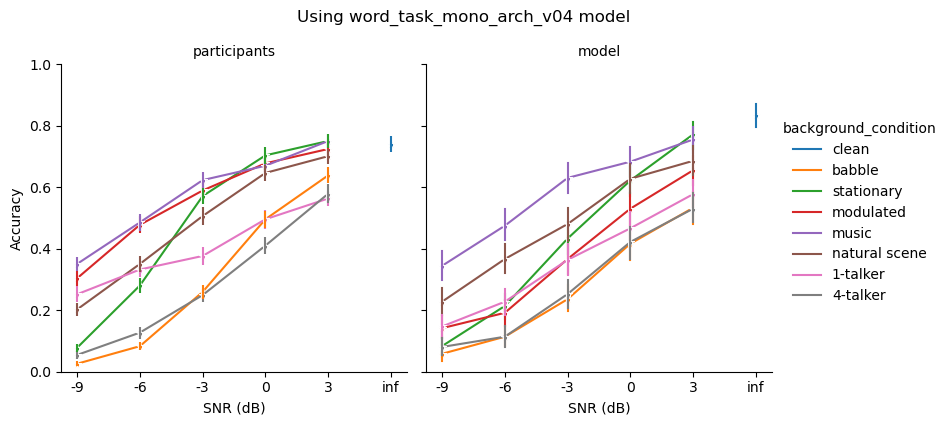

In [18]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model == 'model':
        continue 
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
plt.suptitle(f"Using {model_name} model", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using word_task_mono_arch_v04 model')

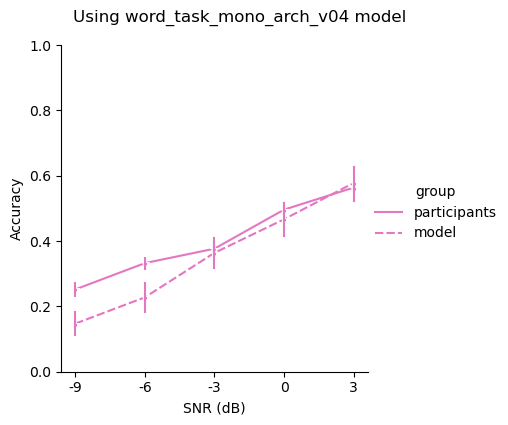

In [19]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker"])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', color=palette['1-talker'],
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', style='group', style_order=['participants', 'model'],
                    marker='*',  height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
data = to_plot[to_plot['group'].eq('participants')]
    # select the data for each hue group
selected = data.groupby('background_condition').get_group('1-talker')
# plot the errorbar with the correct color for each group   
    # plot the errorbar with the correct color for each group 
g.axes[0][0].errorbar(data=selected, x="snr", y="accuracy", yerr="conf_std_error", color=palette['1-talker'], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)

# color lines in legend by hue
leg = g._legend
for lh in leg.legendHandles: 
    lh.set_color(palette['1-talker'])

plt.suptitle(f"Using {model_name} model", y=1.05)

# plt.tight_layout()

Text(0.5, 1.05, 'Using word_task_mono_arch_v04 model')

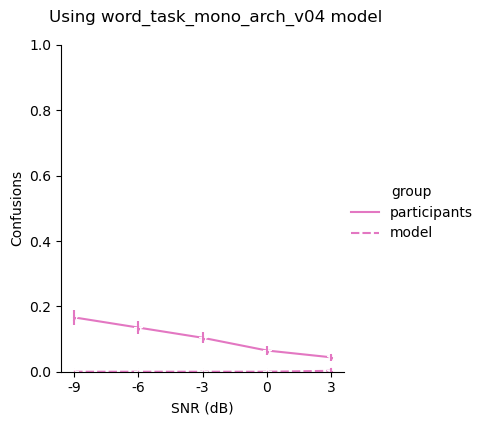

In [20]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker"])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='confusions', color=palette['1-talker'],
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', style='group', style_order=['participants', 'model'],
                    marker='*',  height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Confusions")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
data = to_plot[to_plot['group'].eq('participants')]
    # select the data for each hue group
selected = data.groupby('background_condition').get_group('1-talker')
# plot the errorbar with the correct color for each group   
    # plot the errorbar with the correct color for each group 
g.axes[0][0].errorbar(data=selected, x="snr", y="confusions", yerr="conf_std_error", color=palette['1-talker'], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)

# color lines in legend by hue
leg = g._legend
for lh in leg.legendHandles: 
    lh.set_color(palette['1-talker'])
plt.suptitle(f"Using {model_name} model", y=1.05)

# plt.tight_layout()

### Scatter plot of human vs model performance

In [21]:
from scipy import stats


Text(0.5, 1.05, 'Using word_task_mono_arch_v04 model')

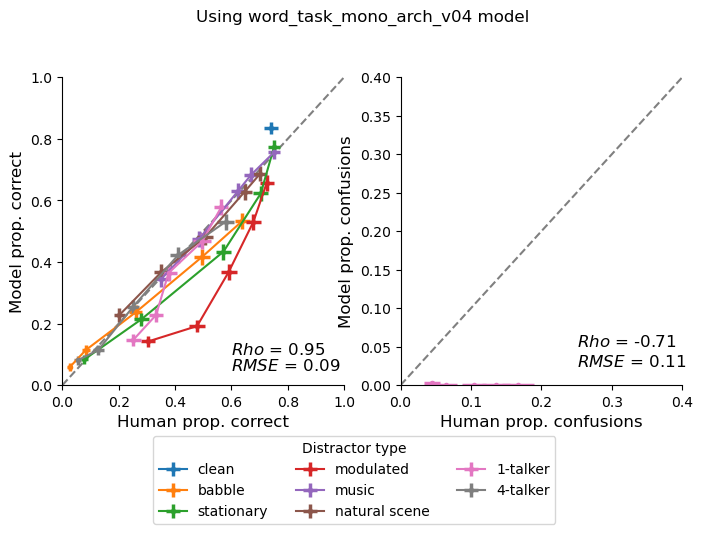

In [22]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]
palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 12

fig, axs = plt.subplots(1,2, figsize=(8,4))

# for ix, group in enumerate(grouped_results.group.unique()):
axs[0].plot(x,y, ls='dashed', color='grey')
axs[1].plot(x,y, ls='dashed', color='grey')
    # axs[1,ix].plot(x,y, ls='dashed', color='grey')
model_df = grouped_results[grouped_results.group == 'model']
# summarize model data
model_df = model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']


human_df = grouped_results[grouped_results.group == 'participants']

for condition in hue_order:
    # plot acc 
    human_data = human_df[human_df.background_condition == condition]
    human_means = human_data["accuracy"].values
    human_errors = human_data["acc_std_error"].values

    model_data = model_df[model_df.background_condition == condition]
    model_means = model_data["accuracy"].values
    model_errors = model_data["acc_std_error"].values

    axs[0].errorbar(x=human_means, y=model_means, xerr=human_errors, yerr=model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        ecolor=palette[condition], mfc=palette[condition], mec=palette[condition])

# # plot confusions
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["confusions"].values
human_conf_errors = human_conf_data["conf_std_error"].values

model_conf_data = model_df[model_df.background_condition ==  "1-talker"]
model_conf_means = model_conf_data["confusions"].values
model_conf_errors = model_conf_data["conf_std_error"].values

axs[1].errorbar(x=human_conf_means, y=model_conf_means, xerr=human_conf_errors, yerr=model_conf_errors, marker='o', linestyle='None', ms=3, elinewidth=2.5, label= "1-talker",
                    ecolor=palette[ "1-talker"], mfc=palette[ "1-talker"], mec=palette[ "1-talker"])

        

axs[0].set_xlim(0,1)
axs[0].set_ylim(0,1)

axs[1].set_xlim(0,0.4)
axs[1].set_ylim(0,0.4)

axs[0].set_xlabel(f"Human prop. correct", fontsize=fontsize)
axs[1].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

# acc errors 
res = stats.spearmanr(human_df["accuracy"].values,  model_df['accuracy'].values)
rho = res.statistic
axs[0].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.1), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - model_df['accuracy'].values)**2))
axs[0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

# conf errors 
res = stats.spearmanr(human_conf_means, model_conf_means)
rho = res.statistic
axs[1].annotate(f"$Rho$ = {rho:.2f}", (0.25, 0.05), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_conf_means - model_conf_means)**2))
axs[1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.25, 0.025), fontsize=fontsize)


axs[0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1].set_ylabel(f"Model prop. confusions", fontsize=fontsize)
sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
# plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()
# 

plt.suptitle(f"Using {model_name} model", y=1.05)



Text(0.5, 1.05, 'Using word_task_mono_arch_v04 model')

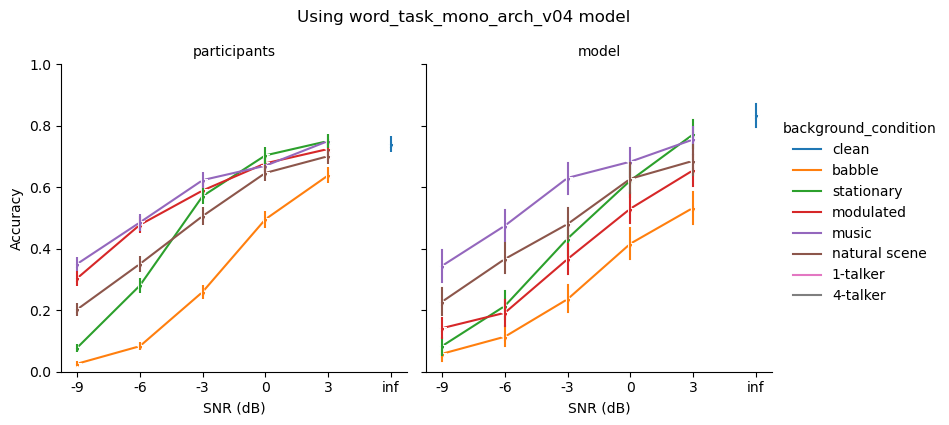

In [23]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                err_style='bars', errorbar=('ci', 95),
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Using {model_name} model", y=1.05)

# plt.tight_layout()

Text(0.5, 1.05, 'Using word_task_mono_arch_v04 model')

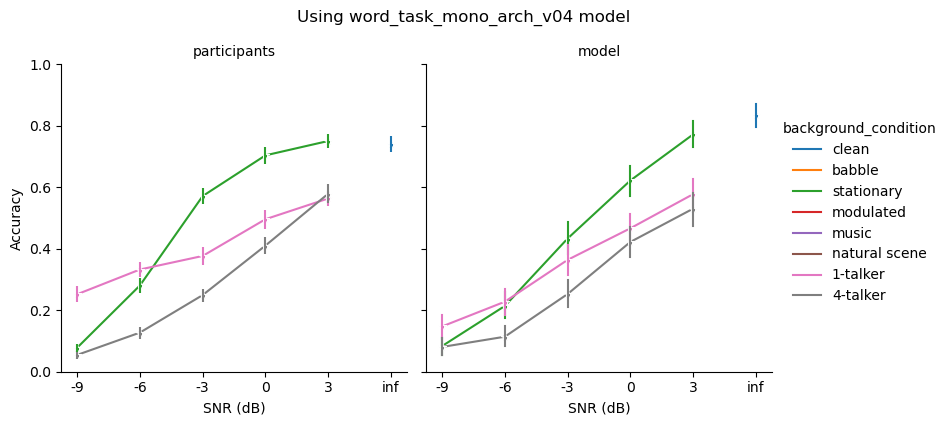

In [24]:

# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot_list = ["1-talker", "4-talker", "clean", "babble"]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker", "4-talker", "clean", "stationary"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above
    if model == 'model':
        continue
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Using {model_name} model", y=1.05)


# plt.tight_layout()

In [25]:
# part_summary_df.rename(columns={'mean': 'accuracy', 'condition': "background_condition"}, inplace=True)

In [26]:
part_summary_df.snr.unique()

array([-9, -6, -3,  0,  3,  6])

## Move on to f0 / gender analysis 

In [43]:
model_f0_df.head()


,pred_word_int,true_word_int,accuracy,model,background_condition,snr,pred_word,true_word,condition,word,word_int,target_gender,target_f0,distractor_f0,distractor_gender,distractor_word,confusions,gender_cond,abs_f0_diff,percent_f0_diff
0,418,418,1,word_task_mono_arch_v04,1-talker,-3,matter,matter,1-talker,matter,403.0,female,194.115145,167.229783,female,charge,0,same,26.885362,0.861498
1,684,191,0,word_task_mono_arch_v04,1-talker,-3,still,defense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,different,NaN,NaN
2,794,297,0,word_task_mono_arch_v04,1-talker,-3,794,given,1-talker,given,287.0,male,131.705872,118.191066,male,player,0,same,13.514806,0.897386
3,562,559,0,word_task_mono_arch_v04,1-talker,-3,quality,provided,1-talker,provided,543.0,male,109.782573,243.292780,female,chinese,0,different,133.510208,2.216133
4,161,26,0,word_task_mono_arch_v04,1-talker,-3,continue,almost,1-talker,almost,22.0,female,188.370054,155.914493,male,entered,0,different,32.455560,0.827703


In [44]:
# combine f0_analysis_df and model_f0_df keeping only columns in both
model_f0_df['id_subject'] = 'model'
model_f0_df['group'] = 'model'
f0_analysis_df['group'] = 'participants'

f0_analysis_df.reset_index(inplace=True, drop=True)
model_f0_df.reset_index(inplace=True, drop=True)
combined_f0_df = pd.concat([f0_analysis_df, model_f0_df],axis=0, ignore_index=True)
# drop columns not in both
combined_f0_df.id_subject.nunique()

/tmp/ipykernel_23032/198012856.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['id_subject'] = 'model'
/tmp/ipykernel_23032/198012856.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['group'] = 'model'


78

In [45]:
# combined_f0_df.drop(columns=['index'], inplace=True)

In [46]:
combined_f0_df['correct_str'] = combined_f0_df['accuracy'].replace({0: "Miss", 1:"Hit"})

In [47]:
combined_f0_df[combined_f0_df.group == 'participants']

,time_elapsed,internal_node_id,output_filename,id_random,id_study,id_subject,id_session,id_version,hc_passed,rt,...,group,pred_word_int,true_word_int,model,pred_word,true_word,condition,word,word_int,correct_str
0,240302.0,0.0-12.0-1.0-1.4,cocktail_party_word_recognition_short/data/sub...,zqt3bl4kyv,6558197da1763c75c51fa6cd,63cfff24ff982236dc481d96,655822e72aa62dd31aab9697,4.0,True,4051.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
1,366938.0,0.0-12.0-1.0-1.13,cocktail_party_word_recognition_short/data/sub...,zqt3bl4kyv,6558197da1763c75c51fa6cd,63cfff24ff982236dc481d96,655822e72aa62dd31aab9697,4.0,True,5413.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
2,419270.0,0.0-12.0-1.0-1.17,cocktail_party_word_recognition_short/data/sub...,zqt3bl4kyv,6558197da1763c75c51fa6cd,63cfff24ff982236dc481d96,655822e72aa62dd31aab9697,4.0,True,4212.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
3,555306.0,0.0-12.0-1.0-1.27,cocktail_party_word_recognition_short/data/sub...,zqt3bl4kyv,6558197da1763c75c51fa6cd,63cfff24ff982236dc481d96,655822e72aa62dd31aab9697,4.0,True,3086.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
4,621050.0,0.0-12.0-1.0-1.32,cocktail_party_word_recognition_short/data/sub...,zqt3bl4kyv,6558197da1763c75c51fa6cd,63cfff24ff982236dc481d96,655822e72aa62dd31aab9697,4.0,True,7812.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,2108908.0,0.0-12.0-1.0-1.164,cocktail_party_word_recognition_short/data/sub...,ctx77q7lkg,6558197da1763c75c51fa6cd,64189ea918b2fee8a9504b32,6558288dc6d84395709e68b6,4.0,True,1478.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
2306,2117132.0,0.0-12.0-1.0-1.165,cocktail_party_word_recognition_short/data/sub...,ctx77q7lkg,6558197da1763c75c51fa6cd,64189ea918b2fee8a9504b32,6558288dc6d84395709e68b6,4.0,True,2462.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Miss
2307,2156237.0,0.0-12.0-1.0-1.169,cocktail_party_word_recognition_short/data/sub...,ctx77q7lkg,6558197da1763c75c51fa6cd,64189ea918b2fee8a9504b32,6558288dc6d84395709e68b6,4.0,True,1206.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hit
2308,2205013.0,0.0-12.0-1.0-1.173,cocktail_party_word_recognition_short/data/sub...,ctx77q7lkg,6558197da1763c75c51fa6cd,64189ea918b2fee8a9504b32,6558288dc6d84395709e68b6,4.0,True,19450.0,...,participants,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Miss


Text(0.5, 0, 'dB SNR')

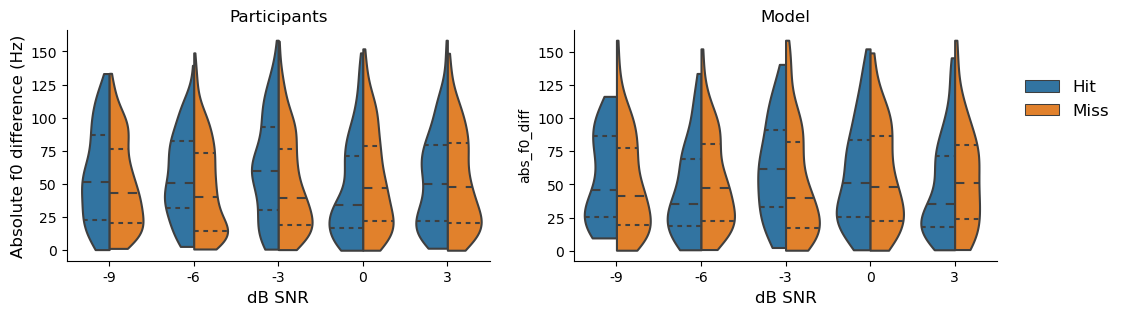

In [48]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
fig, axes = plt.subplots(1,2,figsize=(12,3))
to_plot = combined_f0_df[combined_f0_df.background_condition == '1-talker']
ax = sns.violinplot(data=to_plot[to_plot.group == 'participants'], x="snr", y="abs_f0_diff", cut=0, 
                     hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[0])
ax1 = sns.violinplot(data=to_plot[to_plot.group ==  'model'], x="snr", y="abs_f0_diff",cut=0, 
                      hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[1])

ax.legend().remove()
ax.set_title('Participants')
ax1.set_title('Model')
sns.move_legend(ax1, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
ax.set_ylabel('Absolute f0 difference (Hz)', fontsize=fontsize)
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)
ax.set_xlabel('dB SNR', fontsize=fontsize)
ax1.set_xlabel('dB SNR', fontsize=fontsize)

/tmp/ipykernel_23032/137856591.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot["f0_diff_rounded"] = round(to_plot.abs_f0_diff / 25) * 25


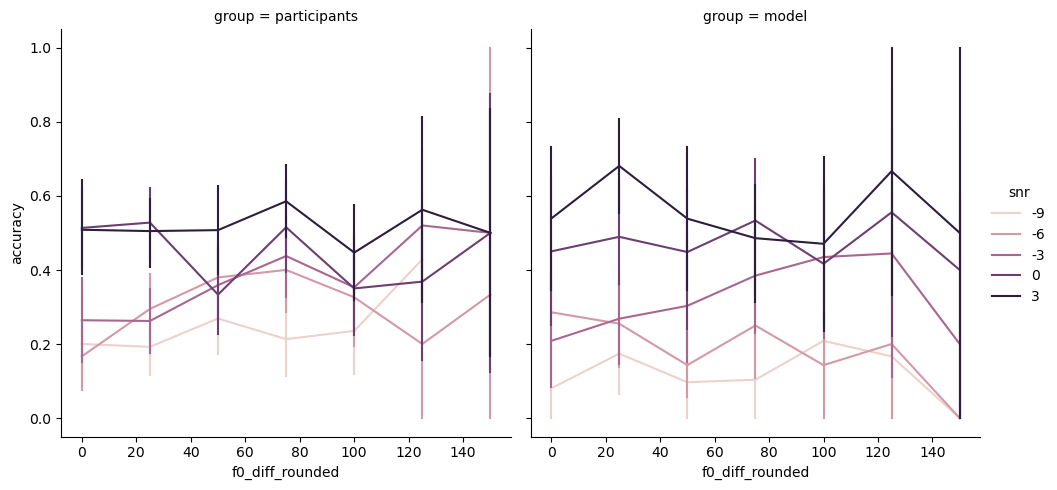

In [49]:
# g = sns.relplot(data=combined_f0_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=combined_f0_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
# round abs f0 diff to nearest 12
to_plot = combined_f0_df[(combined_f0_df.background_condition == '1-talker')] 
to_plot["f0_diff_rounded"] = round(to_plot.abs_f0_diff / 25) * 25

ax = sns.relplot(data=to_plot, x="f0_diff_rounded", y="accuracy", hue='snr', col='group', 
                 kind='line', aspect=1, err_style="bars", errorbar=("ci",95),)
# sns.move_legend(ax, title='', 
#                 loc="center right", bbox_to_anchor=(1.5, .7),
#                 frameon=False, )
# sns.despine()
# sns.despine()
# ax.set_ylabel('f0 difference (Hz)', fontsize=fontsize)
# ax.set_xlabel('dB SNR', fontsize=fontsize)

In [50]:
combined_f0_df.background_condition.unique()

array(['1-talker', 'clean'], dtype=object)

In [51]:
# get trial data excluding catch trials 


human_gender_cond = (combined_f0_df.groupby(["snr", 'id_subject', "gender_cond"])
                     .agg({"accuracy":"mean", "confusions": "mean"})
                     .reset_index())

human_gender_cond['group'] = 'participants'

model_gender_cond = (combined_f0_df[combined_f0_df.group == 'model'].groupby(["snr", "gender_cond"])
                     .agg({"accuracy":"mean", "confusions": "mean"})
                     .reset_index())
model_gender_cond['group'] = 'model'

gender_cond_df = pd.concat([human_gender_cond, model_gender_cond], axis=0)
gender_cond_df.loc[gender_cond_df.snr == np.inf, 'snr'] = 6
gender_cond_df.loc[gender_cond_df.snr == "inf", 'snr'] = 6
gender_cond_df.loc[gender_cond_df.snr == 6, "gender_cond"] = "clean"
gender_cond_df.loc[gender_cond_df.snr == 6, "background_condition"] = "clean"
gender_cond_df.loc[gender_cond_df.snr < 6, "background_condition"] = "1-talker"

/tmp/ipykernel_23032/25578451.py:1: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(data=gender_cond_df, x='snr', y='accuracy', hue='gender_cond', kind='line', col='group', col_order=['participants', 'model'],


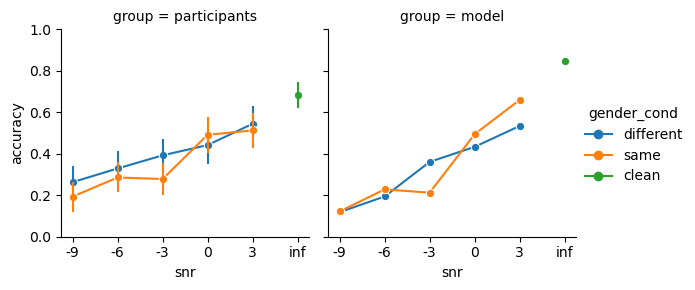

In [52]:
g = sns.relplot(data=gender_cond_df, x='snr', y='accuracy', hue='gender_cond', kind='line', col='group', col_order=['participants', 'model'],
                err_style = 'bars', style="gender_cond", markers="o", dashes=False, errorbar=('se', 2), height=3)

x_tick_locs = gender_cond_df.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'

for ax in g.axes.flat:
# labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    plt.ylim(0,1)


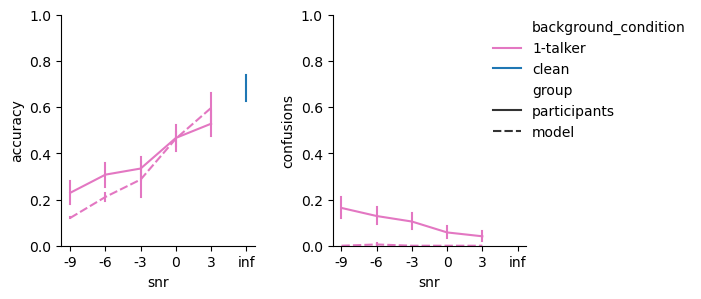

In [53]:
fig, axs = plt.subplots(1,2, figsize=(6,3))

g = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'accuracy', err_style='bars',
                  style='group', style_order=['participants', 'model'], 
                  hue='background_condition', palette=palette,
            ax=axs[0])

g1 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'confusions',  err_style='bars', 
                   style='group',style_order=['participants', 'model'], 
                   hue='background_condition', palette=palette,
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()
# remove legend titles 
g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(.8, 1), loc=2, borderaxespad=0., title='')
